## Import the functions 

In [323]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd 
pd.set_option('display.max_columns', None)  # display all the columns
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors

## 1. Load data and preview basic information

In [324]:
data = pd.read_csv('marketing_campaign.csv',sep = '\t')
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [325]:
data.shape

(2240, 29)

In [326]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [327]:
print("check weather null value exist:")
data.isnull().sum()

check weather null value exist:


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [328]:
# Fill missing values with median to ensure data consistency and avoid errors.
data['Income'].fillna(data['Income'].median(), inplace=True)

In [329]:
print('after fillna value , check again:')
data.isnull().sum()

after fillna value , check again:


ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [330]:
# Find categorical variables
print("Number of unique values in categorical variables:")
data.select_dtypes(include=['object']).nunique()

Number of unique values in categorical variables:


Education           5
Marital_Status      8
Dt_Customer       663
dtype: int64

In [331]:
# Identify unique values in these two categories
data['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [332]:
data['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [333]:
# Check unique values in Z_CostContact and Z_Revenue
data['Z_CostContact'].value_counts()

Z_CostContact
3    2240
Name: count, dtype: int64

In [334]:
data['Z_Revenue'].value_counts()

Z_Revenue
11    2240
Name: count, dtype: int64

In [335]:
#Both columns have constant or non-informative values, would be removed because of irrelevancy

## 2. Feature processing: Transform and construct new features to enhance data usability.

### 2.1 create class Feature Processor
##### Purpose:constructing new features and transforming existing ones to improve usability for analysis or modeling, taking a DataFrame as input and returning an updated DataFrame with added features.
##### Modifications have made: 1.Added dayfirst=True in date conversion to ensure correct parsing for non-US date formats.2.Added Monetary and Frequency calculations to aggregate spending and purchase activity across categories. Because I consider RFM (Recency, Frequency, Monetary) to be useful features for customer segmentation and behaviour analysis, enabling better customer segmentation


In [336]:
class FeatureProcessor:
    def __init__(self,data):  #initialize and store the dataset
        self.data = data

    def build_features(self): #Build new features to enhance the dataset for analysis or modeling
        #Convert 'Dt_Customer' to datetime for date-based calculations
        self.data['Dt_Customer'] = pd.to_datetime(self.data['Dt_Customer'],dayfirst=True) 
        #number of days the customers started to shop in the store relative to the last recorded date
        self.data['Customer_For']  = (self.data['Dt_Customer'].max() - self.data['Dt_Customer'] ).dt.days  
        #Age of customer
        self.data["Age"] = 2025 - self.data["Year_Birth"] 
        # Simplify marital status into 'Living_With'
        self.data["Living_With"]=self.data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})
        # Total number of children
        self.data["Children"]=self.data["Kidhome"]+data["Teenhome"]
        # Calculate family size
        self.data["Family_Size"] = self.data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]
        # Determine if the customer is a parent
        self.data["Is_Parent"] = np.where(data.Children> 0, 1, 0)
        # Simplify education levels
        self.data["Education"]=self.data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})
        # Monetary: Total spending across all product categories
        self.data['Monetary'] = (self.data['MntWines'] + self.data['MntFruits'] + self.data['MntMeatProducts'] +
                            self.data['MntFishProducts'] + self.data['MntSweetProducts'] + self.data['MntGoldProds'])
        
        # Frequency: Total number of purchases made in this period
        self.data['Frequency'] = (self.data['NumDealsPurchases'] + self.data['NumWebPurchases'] + 
                             self.data['NumCatalogPurchases'] + self.data['NumStorePurchases'])

        #self.data = self.data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})
        #self.data.drop(columns  = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds'])
        # ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
        return self.data

In [337]:
processor = FeatureProcessor(data)
data = processor.build_features()
print('after build new feature , data is below:')
data

after build new feature , data is below:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_For,Age,Living_With,Children,Family_Size,Is_Parent,Monetary,Frequency
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,663,68,Alone,0,1,0,1617,25
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,113,71,Alone,2,3,1,27,6
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,312,60,Partner,0,2,0,776,21
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,139,41,Partner,1,3,1,53,8
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,161,44,Partner,1,3,1,422,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduate,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0,381,58,Partner,1,3,1,1341,18
2236,4001,1946,Postgraduate,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0,19,79,Partner,3,5,1,444,22
2237,7270,1981,Graduate,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0,155,44,Alone,0,1,0,1241,19
2238,8235,1956,Postgraduate,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0,156,69,Partner,1,3,1,843,23


### 2.2 Remove columns that are unnecessary or already replaced

In [338]:
cols_del1 = ['Year_Birth','Z_Revenue','Z_CostContact','Dt_Customer','AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
cols_del2 = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
cols_del = cols_del1 + cols_del2
data = data.drop(cols_del, axis=1)
print("dataset with selected features:")
data.head()

dataset with selected features:


,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Living_With,Children,Family_Size,Is_Parent,Monetary,Frequency
0,5524,Graduate,Single,58138.0,0,0,58,3,8,10,4,7,663,68,Alone,0,1,0,1617,25
1,2174,Graduate,Single,46344.0,1,1,38,2,1,1,2,5,113,71,Alone,2,3,1,27,6
2,4141,Graduate,Together,71613.0,0,0,26,1,8,2,10,4,312,60,Partner,0,2,0,776,21
3,6182,Graduate,Together,26646.0,1,0,26,2,2,0,4,6,139,41,Partner,1,3,1,53,8
4,5324,Postgraduate,Married,58293.0,1,0,94,5,5,3,6,5,161,44,Partner,1,3,1,422,19


In [339]:
print("basic statistic distribution of the processed features:")
data.describe()

basic statistic distribution of the processed features:


,ID,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Children,Family_Size,Is_Parent,Monetary,Frequency
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,52237.975446,0.444196,0.506250,49.109375,2.325000,4.084821,2.662054,5.790179,5.316518,353.582143,56.194196,0.950446,2.595089,0.715179,605.798214,14.862054
std,3246.662198,25037.955891,0.538398,0.544538,28.962453,1.932238,2.778714,2.923101,3.250958,2.426645,202.122512,11.984069,0.751803,0.906959,0.451430,602.249288,7.677173
min,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,0.000000,1.000000,0.000000,5.000000,0.000000
25%,2828.250000,35538.750000,0.000000,0.000000,24.000000,1.000000,2.000000,0.000000,3.000000,3.000000,180.750000,48.000000,0.000000,2.000000,0.000000,68.750000,8.000000
50%,5458.500000,51381.500000,0.000000,0.000000,49.000000,2.000000,4.000000,2.000000,5.000000,6.000000,355.500000,55.000000,1.000000,3.000000,1.000000,396.000000,15.000000
75%,8427.750000,68289.750000,1.000000,1.000000,74.000000,3.000000,6.000000,4.000000,8.000000,7.000000,529.000000,66.000000,1.000000,3.000000,1.000000,1045.500000,21.000000
max,11191.000000,666666.000000,2.000000,2.000000,99.000000,15.000000,27.000000,28.000000,13.000000,20.000000,699.000000,132.000000,3.000000,5.000000,1.000000,2525.000000,44.000000


## 3. Identify and exclude the outliers

##### I decided to use pair plots because they can visualise relationships and highlight data points that deviate significantly, helping to identify outliers. 

<Figure size 1500x1000 with 0 Axes>

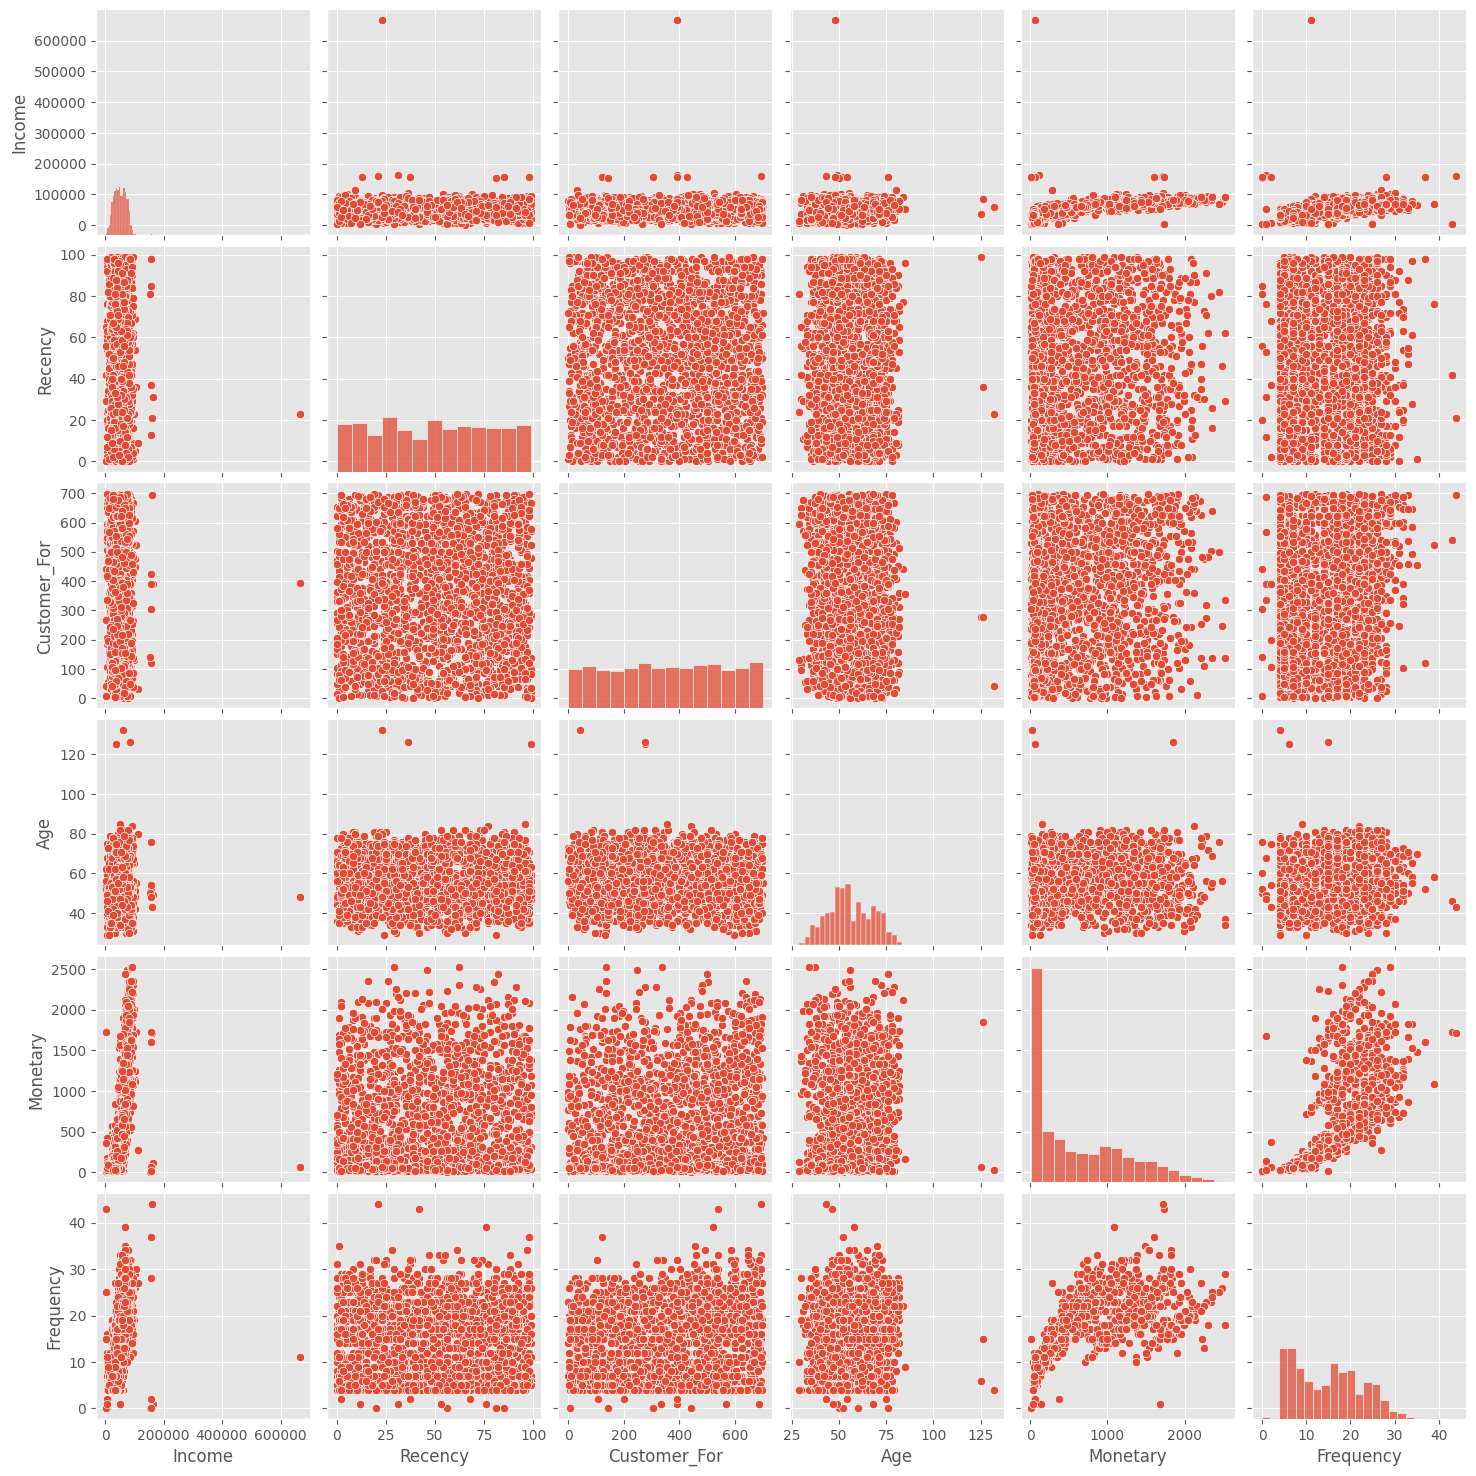

In [340]:
To_Plot = [ "Income", "Recency", "Customer_For", "Age", "Monetary","Frequency"]
plt.figure()
sns.pairplot(data[To_Plot])
plt.show()

##### I identify outliers are in the 'Age' column (age < 90) and 'Income' column (income < 400,000)from the plot

In [341]:
data = data[(data["Age"]<90)]
data = data[(data["Income"]<400000)]
print("The total number of data-points after removing the outliers are:", len(data))

The total number of data-points after removing the outliers are: 2236


In [342]:
data.dtypes

ID                       int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Recency                  int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Customer_For             int64
Age                      int64
Living_With             object
Children                 int64
Family_Size              int64
Is_Parent                int64
Monetary                 int64
Frequency                int64
dtype: object

In [343]:
#identify string columns that need to be encoded in the future
string_columns = list(data.select_dtypes(include=['object']).columns)
print("string_columns:")
string_columns

string_columns:


['Education', 'Marital_Status', 'Living_With']

In [344]:
#store a copy for very late data visualisation
data_copy = data.copy()

## 4. Data processing

##### Prepare the dataset by encoding categorical features, normalizing numerical features, reducing dimensions with PCA


### 4.1 Encode string features using manual label encoding

##### This function is: 
##### Encode a categorical column using manual label encoding.
    Purpose:
        - Map unique string values in the specified column to integer labels for machine learning compatibility.
    Inputs:
        - data: DataFrame containing the original data to be modified.
        - column: The name of the column to be encoded.
        - data_copy: A backup copy of the original data to store encoded values.
    Outputs:
        - Updated DataFrame (`data`) with the encoded column replacing the original one.
        - Mapping dictionary (`label_mapping`) showing the relationship between original values and integer labels.

In [345]:
def manual_label_encoder(data, column,data_copy):
    # Identify unique values in the column
    unique_values = data[column].unique()
    
    # Create a mapping dictionary to map each unique value to a unique integer
    label_mapping = {value: idx for idx, value in enumerate(unique_values)}
    print(f"for {column} ,label_mapping is:  ")
    print(label_mapping)
    # Replace the column's string values with their corresponding integer labels
    data[column + '_encoded'] = data[column].map(label_mapping)
    data_copy[column + '_encoded'] = data[column].map(label_mapping)
    data.drop(columns=[column], inplace=True)
    return data, label_mapping



for column in string_columns:
    manual_label_encoder(data, column,data_copy)

for Education ,label_mapping is:  
{'Graduate': 0, 'Postgraduate': 1, 'Undergraduate': 2}
for Marital_Status ,label_mapping is:  
{'Single': 0, 'Together': 1, 'Married': 2, 'Divorced': 3, 'Widow': 4, 'Alone': 5, 'Absurd': 6, 'YOLO': 7}
for Living_With ,label_mapping is:  
{'Alone': 0, 'Partner': 1}


In [346]:
data.head()

,ID,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Children,Family_Size,Is_Parent,Monetary,Frequency,Education_encoded,Marital_Status_encoded,Living_With_encoded
0,5524,58138.0,0,0,58,3,8,10,4,7,663,68,0,1,0,1617,25,0,0,0
1,2174,46344.0,1,1,38,2,1,1,2,5,113,71,2,3,1,27,6,0,0,0
2,4141,71613.0,0,0,26,1,8,2,10,4,312,60,0,2,0,776,21,0,1,1
3,6182,26646.0,1,0,26,2,2,0,4,6,139,41,1,3,1,53,8,0,1,1
4,5324,58293.0,1,0,94,5,5,3,6,5,161,44,1,3,1,422,19,1,2,1


In [347]:
IDs = data['ID']

In [348]:
print("Drop 'ID' column as it does not provide meaningful information for clustering, the updated dataset:")
data.drop(columns=['ID'], inplace=True)
data.head()

Drop 'ID' column as it does not provide meaningful information for clustering, the updated dataset:


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Children,Family_Size,Is_Parent,Monetary,Frequency,Education_encoded,Marital_Status_encoded,Living_With_encoded
0,58138.0,0,0,58,3,8,10,4,7,663,68,0,1,0,1617,25,0,0,0
1,46344.0,1,1,38,2,1,1,2,5,113,71,2,3,1,27,6,0,0,0
2,71613.0,0,0,26,1,8,2,10,4,312,60,0,2,0,776,21,0,1,1
3,26646.0,1,0,26,2,2,0,4,6,139,41,1,3,1,53,8,0,1,1
4,58293.0,1,0,94,5,5,3,6,5,161,44,1,3,1,422,19,1,2,1


### 4.2 Perform min-max scaling on numerical features

Purpose: Normalize all numerical columns to a range of 0 to 1 to ensure consistency in scale for clustering.
Input: DataFrame with numerical columns.
Output: DataFrame with numerical columns scaled to a range of 0 to 1.

In [349]:
def manual_minmax_scaler(data):
    for column in data.select_dtypes(include=['number']).columns:
        min_val = data[column].min()
        max_val = data[column].max()
        data[column] = (data[column] - min_val) / (max_val - min_val)
    
    return data

# Normalize all numerical columns and overwrite the original columns
data = manual_minmax_scaler(data)
print(" The normalized dataset with all numerical values scaled between 0 and 1")
data

 The normalized dataset with all numerical values scaled between 0 and 1


,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Children,Family_Size,Is_Parent,Monetary,Frequency,Education_encoded,Marital_Status_encoded,Living_With_encoded
0,0.351086,0.0,0.0,0.585859,0.200000,0.296296,0.357143,0.307692,0.35,0.948498,0.696429,0.000000,0.00,0.0,0.639683,0.568182,0.0,0.000000,0.0
1,0.277680,0.5,0.5,0.383838,0.133333,0.037037,0.035714,0.153846,0.25,0.161660,0.750000,0.666667,0.50,1.0,0.008730,0.136364,0.0,0.000000,0.0
2,0.434956,0.0,0.0,0.262626,0.066667,0.296296,0.071429,0.769231,0.20,0.446352,0.553571,0.000000,0.25,0.0,0.305952,0.477273,0.0,0.142857,1.0
3,0.155079,0.5,0.0,0.262626,0.133333,0.074074,0.000000,0.307692,0.30,0.198856,0.214286,0.333333,0.50,1.0,0.019048,0.181818,0.0,0.142857,1.0
4,0.352051,0.5,0.0,0.949495,0.333333,0.185185,0.107143,0.461538,0.25,0.230329,0.267857,0.333333,0.50,1.0,0.165476,0.431818,0.5,0.285714,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.370288,0.0,0.5,0.464646,0.133333,0.333333,0.107143,0.307692,0.25,0.545064,0.517857,0.333333,0.50,1.0,0.530159,0.409091,0.0,0.285714,1.0
2236,0.387659,1.0,0.5,0.565657,0.466667,0.296296,0.071429,0.384615,0.35,0.027182,0.892857,1.000000,1.00,1.0,0.174206,0.500000,0.5,0.142857,1.0
2237,0.343885,0.0,0.0,0.919192,0.066667,0.074074,0.107143,1.000000,0.30,0.221745,0.267857,0.000000,0.00,0.0,0.490476,0.431818,0.0,0.428571,0.0
2238,0.420217,0.0,0.5,0.080808,0.133333,0.222222,0.178571,0.769231,0.15,0.223176,0.714286,0.333333,0.50,1.0,0.332540,0.522727,0.5,0.142857,1.0


### 4.3 Perform PCA for dimensionality reduction


##### Input:
    - a 2D list, where rows represent data points and columns represent features.
    
##### Output:
    - projected_data: The transformed dataset in a lower-dimensional space (a 2D list), where each row is a data point, and columns represent the selected principal components.
    - sorted_eigenvectors: The eigenvectors corresponding to the principal components, sorted by their eigenvalues in descending order.
    
##### Purpose:
    - Transform high-dimensional data into a 3-dimensional space while retaining key information.

In [350]:
data

,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Children,Family_Size,Is_Parent,Monetary,Frequency,Education_encoded,Marital_Status_encoded,Living_With_encoded
0,0.351086,0.0,0.0,0.585859,0.200000,0.296296,0.357143,0.307692,0.35,0.948498,0.696429,0.000000,0.00,0.0,0.639683,0.568182,0.0,0.000000,0.0
1,0.277680,0.5,0.5,0.383838,0.133333,0.037037,0.035714,0.153846,0.25,0.161660,0.750000,0.666667,0.50,1.0,0.008730,0.136364,0.0,0.000000,0.0
2,0.434956,0.0,0.0,0.262626,0.066667,0.296296,0.071429,0.769231,0.20,0.446352,0.553571,0.000000,0.25,0.0,0.305952,0.477273,0.0,0.142857,1.0
3,0.155079,0.5,0.0,0.262626,0.133333,0.074074,0.000000,0.307692,0.30,0.198856,0.214286,0.333333,0.50,1.0,0.019048,0.181818,0.0,0.142857,1.0
4,0.352051,0.5,0.0,0.949495,0.333333,0.185185,0.107143,0.461538,0.25,0.230329,0.267857,0.333333,0.50,1.0,0.165476,0.431818,0.5,0.285714,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.370288,0.0,0.5,0.464646,0.133333,0.333333,0.107143,0.307692,0.25,0.545064,0.517857,0.333333,0.50,1.0,0.530159,0.409091,0.0,0.285714,1.0
2236,0.387659,1.0,0.5,0.565657,0.466667,0.296296,0.071429,0.384615,0.35,0.027182,0.892857,1.000000,1.00,1.0,0.174206,0.500000,0.5,0.142857,1.0
2237,0.343885,0.0,0.0,0.919192,0.066667,0.074074,0.107143,1.000000,0.30,0.221745,0.267857,0.000000,0.00,0.0,0.490476,0.431818,0.0,0.428571,0.0
2238,0.420217,0.0,0.5,0.080808,0.133333,0.222222,0.178571,0.769231,0.15,0.223176,0.714286,0.333333,0.50,1.0,0.332540,0.522727,0.5,0.142857,1.0


In [351]:
import math
import random

class PCAAnalysis:
    def __init__(self, data, num_components=2):
        """
        Initialize the PCAAnalysis class

        :param data: Input sample data (2D list)
        :param num_components: Number of principal components
        """
        self.data = data
        self.num_components = num_components
        self.standardized_data = None
        self.cov_matrix = None
        self.eigenvalues = None
        self.eigenvectors = None
        self.projected_data = None

    def mean_column(self, matrix):
        """Calculate the mean of each column in the matrix"""
        num_rows = len(matrix)
        num_cols = len(matrix[0])
        return [sum(row[i] for row in matrix) / num_rows for i in range(num_cols)]

    def standardize_data(self):
        """Standardize data (zero mean + variance normalization)"""
        num_rows = len(self.data)
        num_cols = len(self.data[0])

        means = self.mean_column(self.data)
        stds = [math.sqrt(sum((row[i] - means[i]) ** 2 for row in self.data) / (num_rows - 1)) for i in range(num_cols)]
        stds = [std if std > 1e-8 else 1 for std in stds]  # Prevent division by zero

        self.standardized_data = [[(self.data[i][j] - means[j]) / stds[j] for j in range(num_cols)] for i in range(num_rows)]
        return self.standardized_data

    def covariance_matrix(self):
        """Calculate the covariance matrix"""
        num_rows = len(self.standardized_data)
        num_cols = len(self.standardized_data[0])

        cov_matrix = [[0] * num_cols for _ in range(num_cols)]
        for i in range(num_cols):
            for j in range(num_cols):
                cov_matrix[i][j] = sum \
                    (self.standardized_data[k][i] * self.standardized_data[k][j] for k in range(num_rows)) / \
                                               (num_rows - 1)

        self.cov_matrix = cov_matrix
        return self.cov_matrix

    def mat_vec_mult(self, matrix, vector):
        """Matrix-vector multiplication"""
        return [sum(matrix[i][j] * vector[j] for j in range(len(vector))) for i in range(len(matrix))]

    def vector_norm(self, vector):
        """Calculate the norm of a vector (Euclidean norm)"""
        return math.sqrt(sum(x ** 2 for x in vector))

    def normalize(self, vector):
        """Normalize a vector"""
        norm = self.vector_norm(vector)
        return [x / norm for x in vector]

    def power_iteration(self, matrix, num_iter=10000, tol=1e-9):
        """Power iteration method to compute the largest eigenvalue and corresponding eigenvector"""
        num_cols = len(matrix)
        eigenvector = [random.random() for _ in range(num_cols)]  # 随机初始化向量
        eigenvalue = 0

        for _ in range(num_iter):
            new_vector = self.mat_vec_mult(matrix, eigenvector)
            new_vector = self.normalize(new_vector)
            new_eigenvalue = sum(
                new_vector[i] * sum(matrix[i][j] * new_vector[j] for j in range(num_cols)) for i in range(num_cols))

            if abs(new_eigenvalue - eigenvalue) < tol:
                break

            eigenvector = new_vector
            eigenvalue = new_eigenvalue

        return eigenvalue, eigenvector

    def compute_eigen(self):
        """Compute the top k eigenvalues and eigenvectors (deflation method)"""
        eigenvalues = []
        eigenvectors = []

        A = [row[:] for row in self.cov_matrix]  # Copy the covariance matrix

        for _ in range(self.num_components):
            eigenvalue, eigenvector = self.power_iteration(A)
            eigenvalues.append(eigenvalue)
            eigenvectors.append(eigenvector)

            # Deflation method (remove the effect of already found eigenvectors)
            for i in range(len(A)):
                for j in range(len(A)):
                    A[i][j] -= eigenvalue * eigenvector[i] * eigenvector[j]

        self.eigenvalues = eigenvalues
        self.eigenvectors = eigenvectors

    def pca(self):
        """Perform PCA dimensionality reduction"""
        self.standardize_data()  # Standardize the data
        self.covariance_matrix()  # Compute the covariance matrix
        self.compute_eigen()  # Compute eigenvalues and eigenvectors

        # Sort eigenvectors by eigenvalues in descending order
        sorted_indices = sorted(range(len(self.eigenvalues)), key=lambda k: self.eigenvalues[k], reverse=True)
        sorted_eigenvectors = [self.eigenvectors[i] for i in sorted_indices[:self.num_components]]

        # Project data
        self.projected_data = [
            [sum(
                self.standardized_data[i][j] * sorted_eigenvectors[k][j] for j in range(len(self.standardized_data[0])))
             for k in range(self.num_components)]
            for i in range(len(self.standardized_data))]

        return self.projected_data, sorted_eigenvectors

pca_analysis = PCAAnalysis(list(data.values), num_components=3)
transformed_data,_ = pca_analysis.pca()


In [352]:
PCA_ds = pd.DataFrame(transformed_data ,columns = ['PC1','PC2','PC3'])
PCA_ds

,PC1,PC2,PC3
0,-3.678606,-0.213665,2.618191
1,2.528322,-0.255188,-1.279792
2,-2.818505,-0.524208,-0.104659
3,2.308993,-1.453231,-0.165149
4,0.473088,0.576527,0.135216
...,...,...,...
2231,-0.825543,1.650173,-0.373498
2232,2.589482,4.199256,-1.049043
2233,-2.811081,-1.750449,0.412374
2234,-1.585324,1.787678,-1.591762


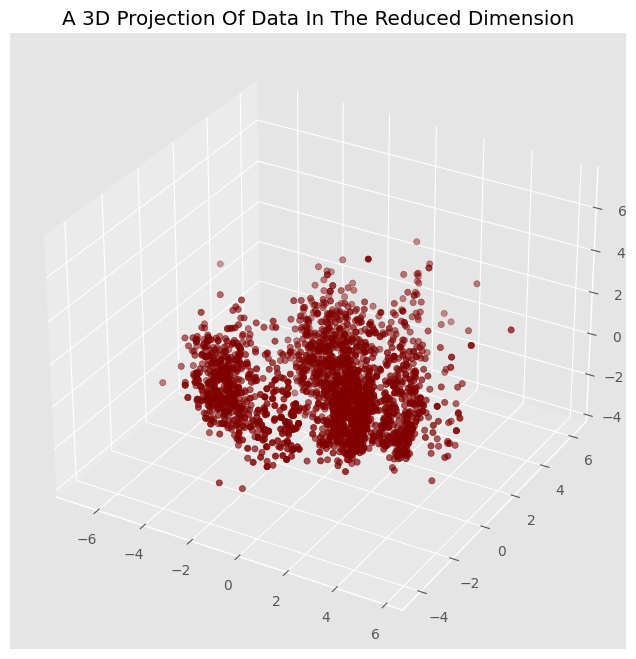

In [353]:
x =PCA_ds["PC1"]
y =PCA_ds["PC2"]
z =PCA_ds["PC3"]
#To plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x,y,z, c="maroon", marker="o" )
ax.set_title("A 3D Projection Of Data In The Reduced Dimension")
plt.show()

## 5. Data Clustering

### For the class MyKmeans
    A manual implementation of the K-Means clustering algorithm.

##### Purpose:
        - Partition data into k clusters based on similarity.
        - Optimize cluster centroids to minimize within-cluster variance.
##### Inputs:
        - k: Number of clusters (default=3).
        - max_iters: Maximum number of iterations to run (default=100).
        - tol: Convergence threshold for centroid updates (default=1e-4).

##### Outputs:
        - centroids: Final cluster centers after convergence. (fit function)
        - labels: Cluster labels for each data point. (predict function)
        - the sum of squared distances (inertia) between points and their cluster centroids.(calculate_inertia function)

### For the function elbow_method
##### Purpose:
        - Plot the sum of squared errors (SSE) for different k values to find the "elbow point".
        - Identify the optimal number of clusters (k) for K-Means.
##### Input:
        - max_k: Maximum number of clusters to test (default=10).
##### Process:
        - Iterate over k values from 1 to max_k.
        - For each k:
            - Fit the MyKMeans model to the dataset.
            - Calculate and store the inertia (SSE) for the current k.
            - Print the SSE for each k to track progress.
##### Output:
        - inertias: A list of SSE values for each k.

when k = 1 , SSE is 23881.17598491899
when k = 2 , SSE is 13542.049099841179
when k = 3 , SSE is 9016.38828212964
when k = 4 , SSE is 8513.83715294583
when k = 5 , SSE is 6607.255635135528
when k = 6 , SSE is 5780.030950391543
when k = 7 , SSE is 5192.951575504525
when k = 8 , SSE is 4800.183983666317
when k = 9 , SSE is 4180.427384490495
when k = 10 , SSE is 3989.387828641664


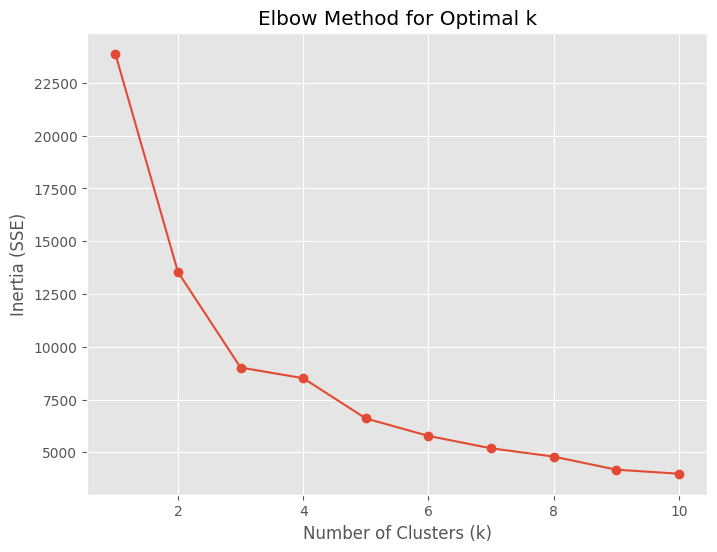

In [354]:
class KMeans:
    def __init__(self, k, max_iters=100, tol=1e-6, random_state=123):
        """
        Initialize the KMeans class

        :param k: Number of clusters
        :param max_iters: Maximum number of iterations
        :param tol: Convergence tolerance, stops iterating if centroid changes are less than tol
        :param random_state: Random seed to ensure consistent results for each run
        """
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state  
        self.centroids = None
        self.labels = None
        self.counter = 0

    def euclidean_distance(self, point1, point2):
        """Calculate the Euclidean distance between two points"""
        distances = []
        for p1, p2 in zip(point1, point2):
            distance = (p1 - p2) ** 2
            distances.append(distance)
            self.counter +=1
        return math.sqrt(sum(distances)) 

    def initialize_centroids(self, data):
        """Randomly initialize centroids"""
        if self.random_state is not None:
            random.seed(self.random_state)  

        return random.sample(data, self.k)

    def assign_labels(self, data):
        """Assign a label to each data point, indicating its cluster"""
        labels = []
        for point in data:
            distances = [self.euclidean_distance(point, centroid) for centroid in self.centroids]
            labels.append(distances.index(min(distances)))  # Assign to the nearest centroid's cluster
            self.counter +=1 
        return labels 

    def update_centroids(self, data, labels):
        """Update centroids based on the current labels"""
        new_centroids = []
        for i in range(self.k):
            # Find all points belonging to cluster i
            cluster_points = [data[j] for j in range(len(data)) if labels[j] == i]
            # Calculate the mean of cluster i as the new centroid (mean for each dimension)
            if cluster_points:
                new_centroids.append([sum(dim) / len(cluster_points) for dim in zip(*cluster_points)])
                self.counter +=1
            else:
                new_centroids.append(self.centroids[i])  # Keep the previous centroid if the cluster is empty
                self.counter +=1
        return new_centroids

    def calculate_inertia(self, data):
        """
        Calculate the inertia (SSE) for KMeans clustering

        param data: Input dataset, formatted as a list of lists
        return: The calculated inertia value
        """
        inertia = 0
        for i, point in enumerate(data):
            # Find the cluster label of the data point
            cluster_idx = self.labels[i]
            # Calculate the squared distance from the data point to the centroid of its cluster
            inertia += self.euclidean_distance(point, self.centroids[cluster_idx]) ** 2
        return inertia

    def fit(self, data):
        """Train KMeans model"""
        self.centroids = self.initialize_centroids(data)  # initialize centroid
        for _ in range(self.max_iters):
            # Assign labels to data points
            labels = self.assign_labels(data)

            # Update centroids
            new_centroids = self.update_centroids(data, labels)

            # Check if centroids have converged
            if all(self.euclidean_distance(c1, c2) < self.tol for c1, c2 in zip(self.centroids, new_centroids)):
                break

            self.centroids = new_centroids
            self.labels = labels
            self.counter +=1
            

    def predict(self, data):
        """Predict the cluster for new data points"""
        return [self.assign_labels([point])[0] for point in data]

    def get_centroids(self):
        """Return the centroids"""
        return self.centroids

    def get_labels(self):
        """Return the cluster labels for each data point"""
        return self.labels
        

# Elbow_method
def elbow_method(X, max_k=10):
    inertias = []
    for k in range(1, max_k + 1):
        model = KMeans(k=k)
        model.fit(X)
        inertias.append(model.calculate_inertia(X))
        print(f'when k = {k} , SSE is {model.calculate_inertia(X)}')
    return inertias

# apply elbow method
inertias = elbow_method(list(PCA_ds.values), max_k=10)

# plot the graph to find the optimal k
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.show()


In [355]:
print("k=4 is optimal as the SSE significantly decreases until k=4, after which the rate of decrease slows, indicating the elbow point.")

k=4 is optimal as the SSE significantly decreases until k=4, after which the rate of decrease slows, indicating the elbow point.


In [356]:
# Apply KMeans with k=4
model = KMeans(k=4)
# Fit the model on the PCA-reduced dataset
model.fit(list(PCA_ds.values))
# Predict cluster labels for the data
clusters = model.predict(list(PCA_ds.values))
# Add cluster labels to the PCA dataset, original data, and backup copy
PCA_ds["Clusters"] = clusters
data['Clusters'] = clusters
data_copy['Clusters'] = clusters
print("PCA dataset with cluster labels")
PCA_ds

PCA dataset with cluster labels


,PC1,PC2,PC3,Clusters
0,-3.678606,-0.213665,2.618191,2
1,2.528322,-0.255188,-1.279792,0
2,-2.818505,-0.524208,-0.104659,2
3,2.308993,-1.453231,-0.165149,0
4,0.473088,0.576527,0.135216,1
...,...,...,...,...
2231,-0.825543,1.650173,-0.373498,1
2232,2.589482,4.199256,-1.049043,1
2233,-2.811081,-1.750449,0.412374,3
2234,-1.585324,1.787678,-1.591762,1


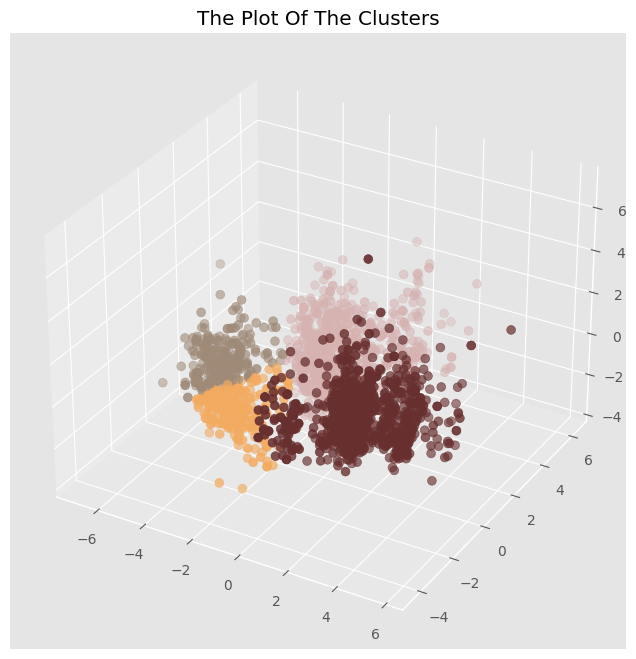

In [357]:
# Visualiation the clusters in 3D to see distribution of clusters
fig = plt.figure(figsize=(10,8))
cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])

ax = plt.subplot(111, projection='3d', label="bla")
ax.scatter(x, y, z, s=40, c=PCA_ds["Clusters"], marker='o', cmap = cmap )
ax.set_title("The Plot Of The Clusters")
plt.show()

## 6. Evaluating the model and visualization

### 6.1 distribution of clusters

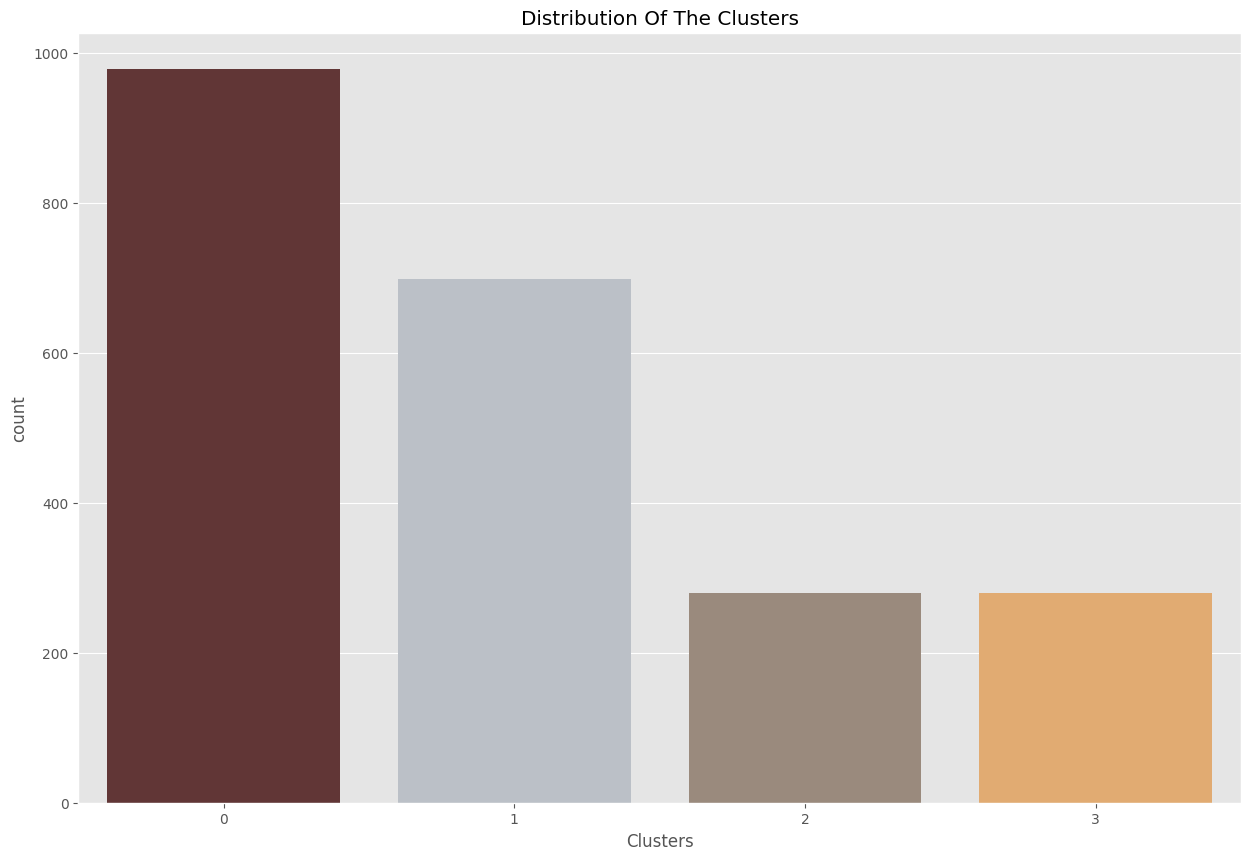

In [358]:
pal = ["#682F2F","#B9C0C9", "#9F8A78","#F3AB60"]
pl = sns.countplot(x=PCA_ds["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

### 6.2 RFM distribution

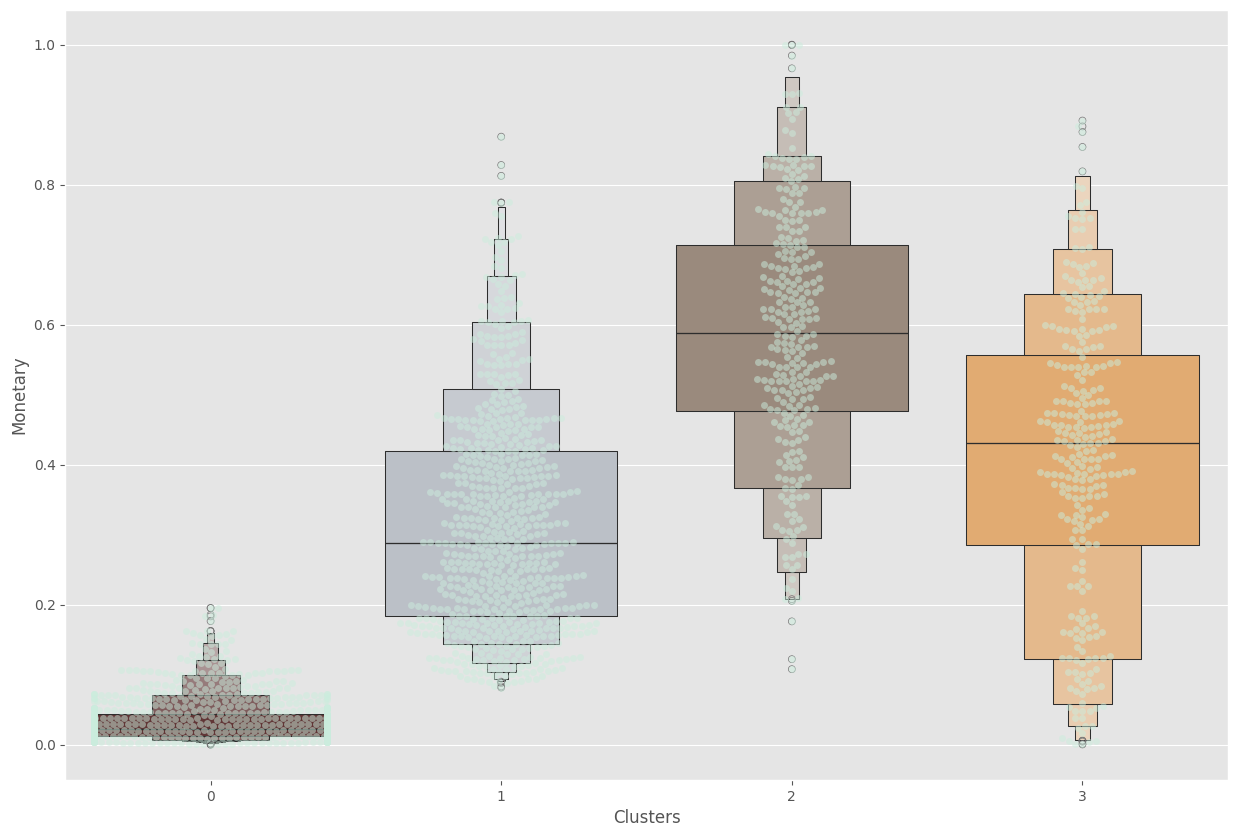

In [359]:
plt.figure()
pl=sns.swarmplot(x=data["Clusters"], y=data["Monetary"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=data["Clusters"], y=data["Monetary"], palette=pal)
plt.show()

In [360]:
data.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Customer_For', 'Age', 'Children', 'Family_Size',
       'Is_Parent', 'Monetary', 'Frequency', 'Education_encoded',
       'Marital_Status_encoded', 'Living_With_encoded', 'Clusters'],
      dtype='object')

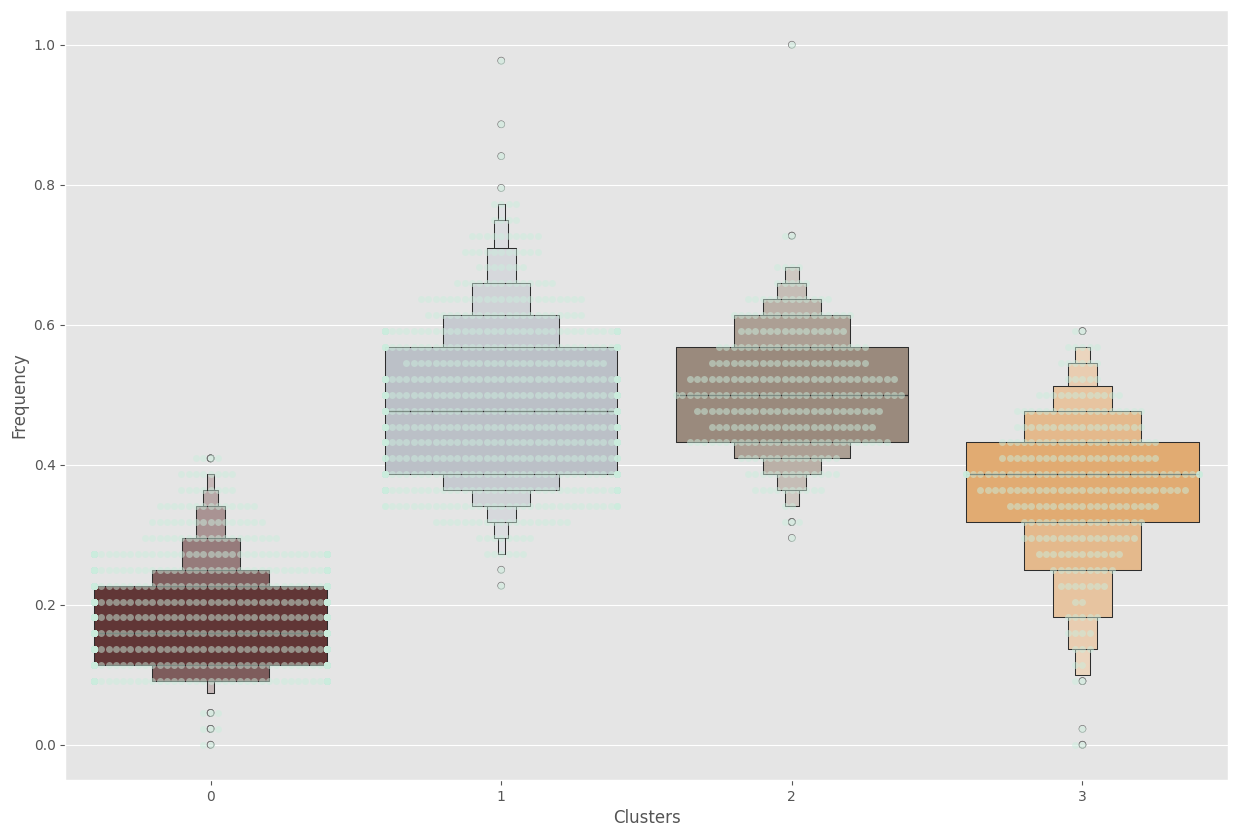

In [361]:
plt.figure()
pl=sns.swarmplot(x=data["Clusters"], y=data["Frequency"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=data["Clusters"], y=data["Frequency"], palette=pal)
plt.show()

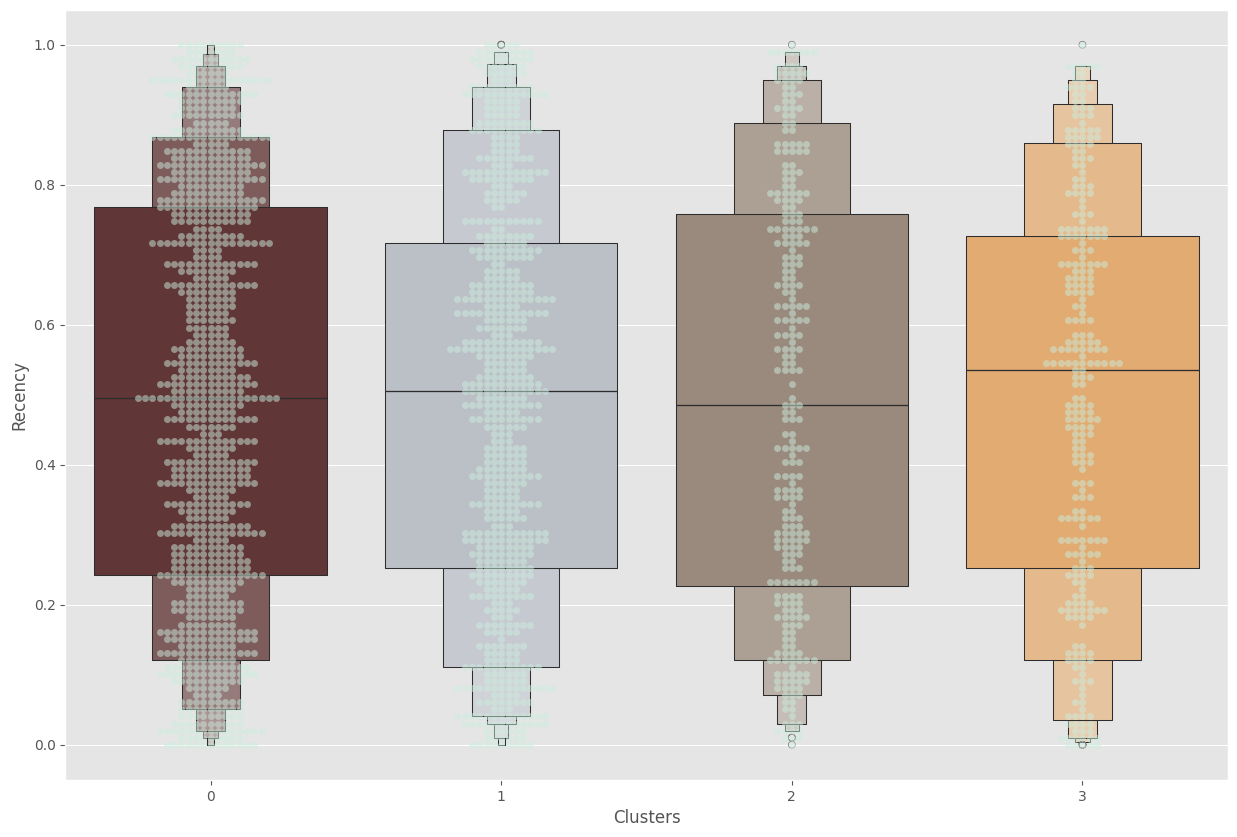

In [362]:
plt.figure()
pl=sns.swarmplot(x=data["Clusters"], y=data["Recency"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=data["Clusters"], y=data["Recency"], palette=pal)
plt.show()

### 6.3 joint plot (I select some from the code I copied)

In [363]:
data.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Customer_For', 'Age', 'Children', 'Family_Size',
       'Is_Parent', 'Monetary', 'Frequency', 'Education_encoded',
       'Marital_Status_encoded', 'Living_With_encoded', 'Clusters'],
      dtype='object')

In [364]:
data

,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Children,Family_Size,Is_Parent,Monetary,Frequency,Education_encoded,Marital_Status_encoded,Living_With_encoded,Clusters
0,0.351086,0.0,0.0,0.585859,0.200000,0.296296,0.357143,0.307692,0.35,0.948498,0.696429,0.000000,0.00,0.0,0.639683,0.568182,0.0,0.000000,0.0,2
1,0.277680,0.5,0.5,0.383838,0.133333,0.037037,0.035714,0.153846,0.25,0.161660,0.750000,0.666667,0.50,1.0,0.008730,0.136364,0.0,0.000000,0.0,0
2,0.434956,0.0,0.0,0.262626,0.066667,0.296296,0.071429,0.769231,0.20,0.446352,0.553571,0.000000,0.25,0.0,0.305952,0.477273,0.0,0.142857,1.0,2
3,0.155079,0.5,0.0,0.262626,0.133333,0.074074,0.000000,0.307692,0.30,0.198856,0.214286,0.333333,0.50,1.0,0.019048,0.181818,0.0,0.142857,1.0,0
4,0.352051,0.5,0.0,0.949495,0.333333,0.185185,0.107143,0.461538,0.25,0.230329,0.267857,0.333333,0.50,1.0,0.165476,0.431818,0.5,0.285714,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.370288,0.0,0.5,0.464646,0.133333,0.333333,0.107143,0.307692,0.25,0.545064,0.517857,0.333333,0.50,1.0,0.530159,0.409091,0.0,0.285714,1.0,1
2236,0.387659,1.0,0.5,0.565657,0.466667,0.296296,0.071429,0.384615,0.35,0.027182,0.892857,1.000000,1.00,1.0,0.174206,0.500000,0.5,0.142857,1.0,1
2237,0.343885,0.0,0.0,0.919192,0.066667,0.074074,0.107143,1.000000,0.30,0.221745,0.267857,0.000000,0.00,0.0,0.490476,0.431818,0.0,0.428571,0.0,3
2238,0.420217,0.0,0.5,0.080808,0.133333,0.222222,0.178571,0.769231,0.15,0.223176,0.714286,0.333333,0.50,1.0,0.332540,0.522727,0.5,0.142857,1.0,1


In [365]:
data_copy['Is_Parent']

0       0
1       1
2       0
3       1
4       1
       ..
2235    1
2236    1
2237    0
2238    1
2239    1
Name: Is_Parent, Length: 2236, dtype: int64

In [366]:
data_copy.isnull().sum()

ID                        0
Education                 0
Marital_Status            0
Income                    0
Kidhome                   0
Teenhome                  0
Recency                   0
NumDealsPurchases         0
NumWebPurchases           0
NumCatalogPurchases       0
NumStorePurchases         0
NumWebVisitsMonth         0
Customer_For              0
Age                       0
Living_With               0
Children                  0
Family_Size               0
Is_Parent                 0
Monetary                  0
Frequency                 0
Education_encoded         0
Marital_Status_encoded    0
Living_With_encoded       0
Clusters                  0
dtype: int64

In [367]:
#data_copy[i]

In [368]:
data_copy["Monetary"]

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Monetary, Length: 2236, dtype: int64

In [369]:
data_copy["Living_With_encoded"]

0       0
1       0
2       1
3       1
4       1
       ..
2235    1
2236    1
2237    0
2238    1
2239    1
Name: Living_With_encoded, Length: 2236, dtype: int64

<Figure size 1500x1000 with 0 Axes>

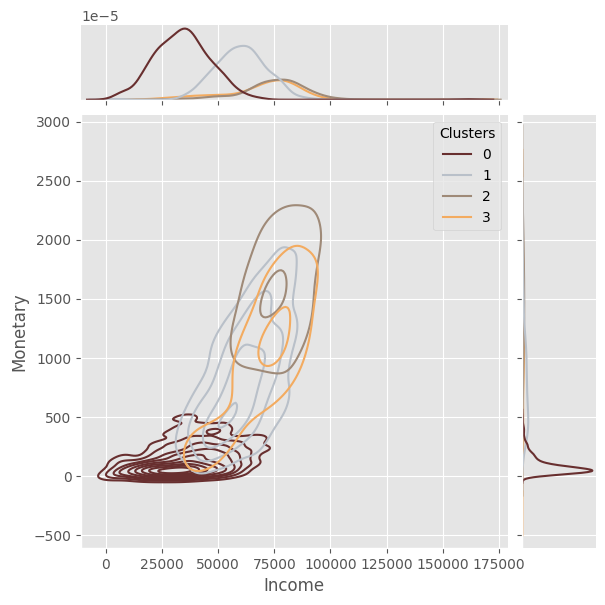

<Figure size 1500x1000 with 0 Axes>

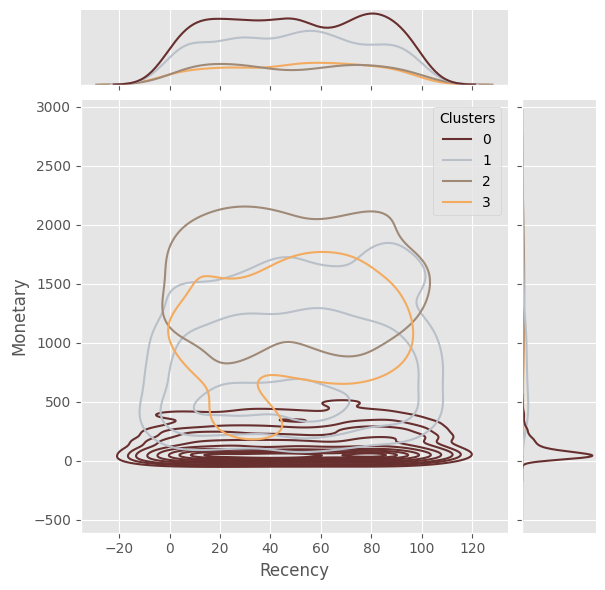

<Figure size 1500x1000 with 0 Axes>

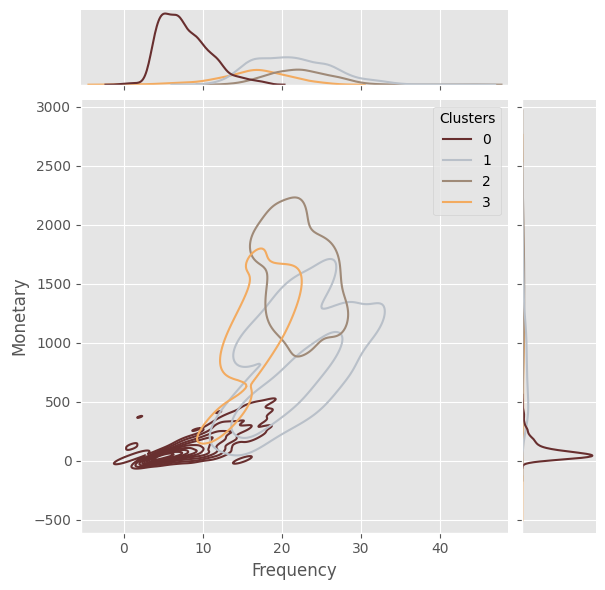

<Figure size 1500x1000 with 0 Axes>

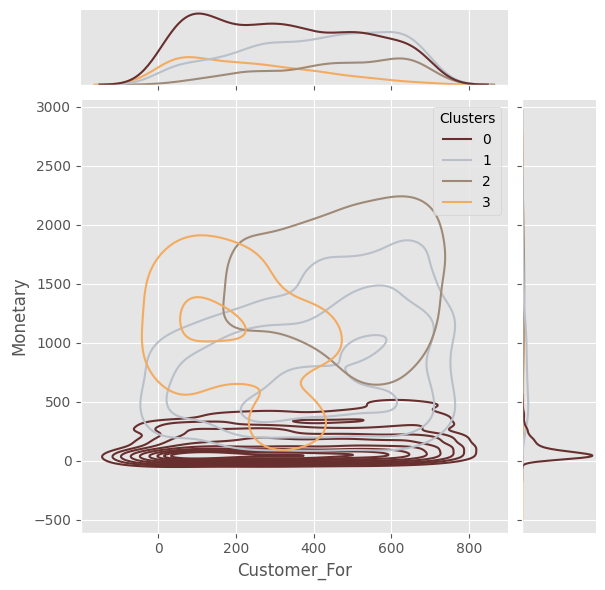

<Figure size 1500x1000 with 0 Axes>

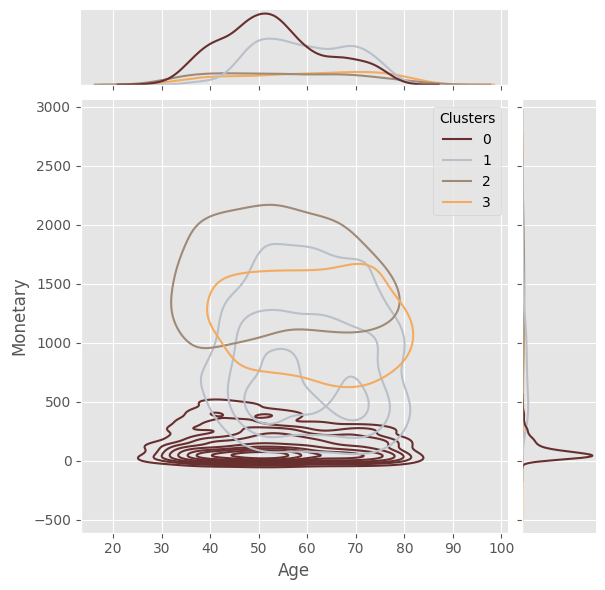

<Figure size 1500x1000 with 0 Axes>

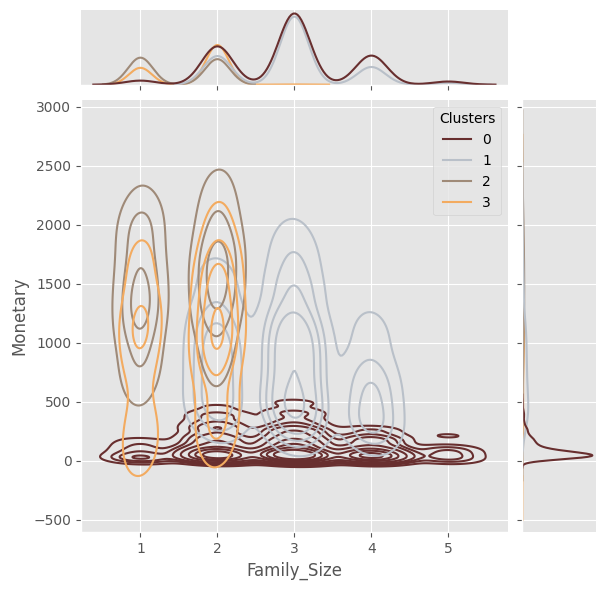

<Figure size 1500x1000 with 0 Axes>

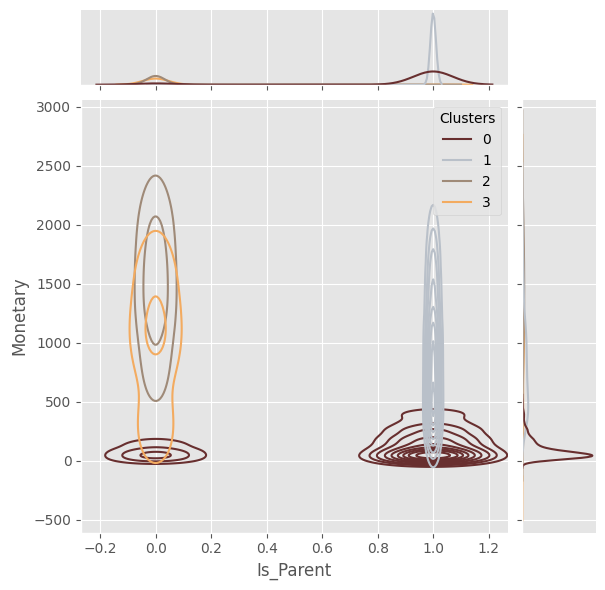

In [370]:
Personal = ['Income','Recency','Monetary','Frequency', "Customer_For", "Age", "Family_Size", "Is_Parent"]

for i in Personal:
    if i == 'Monetary':
        continue
    plt.figure()
    sns.jointplot(x=data_copy[i], y=data_copy["Monetary"], hue =data_copy["Clusters"], kind="kde", palette=pal)
    plt.show()

In [371]:
data_copy['Clusters'] = data['Clusters']

In [372]:
string_columns

['Education', 'Marital_Status', 'Living_With']

### 6.4 RFM Analysis
 (This is the part I added my self, applying dictionaries to demonstrate customer loyalty state)

one of the graph is displayed in html format (I only know this way to display it) overall distribution of dataset on RFM segments

In [373]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

In [374]:
def get_rfm_scores(dataframe):
    # Discretize Recency, Frequency, and Monetary into 5 bins
    dataframe["R"] = pd.qcut(dataframe["Recency"], 5, labels=[5, 4, 3, 2, 1])
    dataframe["F"] = pd.qcut(dataframe["Frequency"].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
    dataframe["M"] = pd.qcut(dataframe["Monetary"], 5, labels=[1, 2, 3, 4, 5])
    # Generate the RFM score based on Recency and Frequency
    dataframe["RFM_SCORE"] = dataframe["R"].astype(str) + dataframe["F"].astype(str) # + dataframe["M"].astype(str) 
    return dataframe

# calculate RFM score
get_rfm_scores(data)
data.reset_index()
#calculate RFM segment
data['segment'] = data['RFM_SCORE'].replace(seg_map, regex = True)
data.head()

,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Children,Family_Size,Is_Parent,Monetary,Frequency,Education_encoded,Marital_Status_encoded,Living_With_encoded,Clusters,R,F,M,RFM_SCORE,segment
0,0.351086,0.0,0.0,0.585859,0.200000,0.296296,0.357143,0.307692,0.35,0.948498,0.696429,0.000000,0.00,0.0,0.639683,0.568182,0.0,0.000000,0.0,2,3,5,5,35,loyal_customers
1,0.277680,0.5,0.5,0.383838,0.133333,0.037037,0.035714,0.153846,0.25,0.161660,0.750000,0.666667,0.50,1.0,0.008730,0.136364,0.0,0.000000,0.0,0,4,1,1,41,promising
2,0.434956,0.0,0.0,0.262626,0.066667,0.296296,0.071429,0.769231,0.20,0.446352,0.553571,0.000000,0.25,0.0,0.305952,0.477273,0.0,0.142857,1.0,2,4,4,4,44,loyal_customers
3,0.155079,0.5,0.0,0.262626,0.133333,0.074074,0.000000,0.307692,0.30,0.198856,0.214286,0.333333,0.50,1.0,0.019048,0.181818,0.0,0.142857,1.0,0,4,2,1,42,potential_loyalists
4,0.352051,0.5,0.0,0.949495,0.333333,0.185185,0.107143,0.461538,0.25,0.230329,0.267857,0.333333,0.50,1.0,0.165476,0.431818,0.5,0.285714,1.0,1,1,4,3,14,at_Risk


In [375]:
# segment visualization
import plotly.express as px
import plotly.io as pio

palette = ["#a7e149","#e149a7", "#c393f4", "#d683f2", "#dd9e9e", "#fa91aa", "#fc9e9e", "#49e183", "#aa91aa", "#ff93f4"]
#pio.renderers.default = 'jupyterlab'

# calculate different segment acounts
x = data.segment.value_counts()

# plot treemap 
fig = px.treemap(x, path=[x.index], values=x, color=x.index, 
                 color_discrete_map={x.index[i]: palette[i % len(palette)] for i in range(len(x.index))})


fig.update_layout(title_text='Distribution of the RFM Segments', title_x=0.5,title_font=dict(size=20))
fig.update_traces(textinfo="label+value+percent root")
fig.show()
#fig.write_image("scatter_plot.png")
#fig.write_html("scatter_plot.html")
fig.write_html("treemap.html")

Visualisation of different clusters' segments
calculate number of clusters and segments

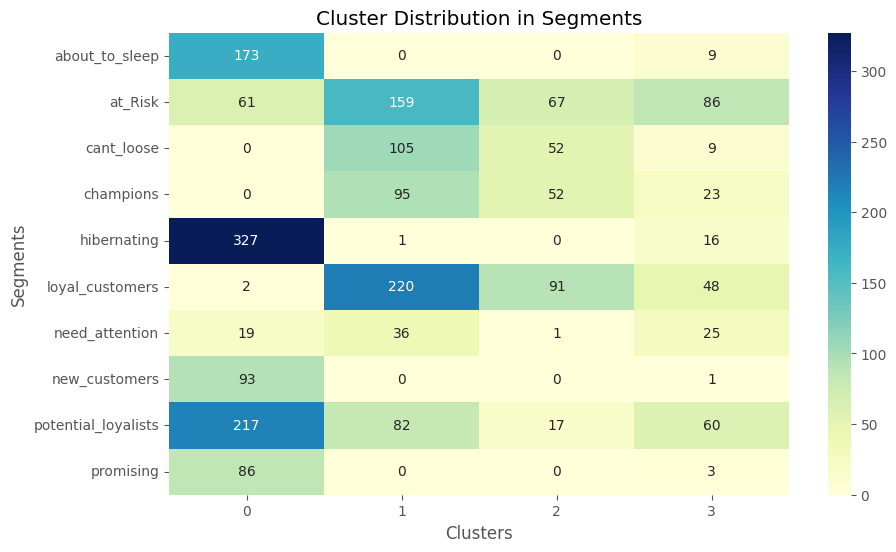

In [379]:
grouped = data.groupby(['Clusters', 'segment']).size().reset_index(name='Count')
# Create a pivot table to reshape the data for plotting
pivot_table = grouped.pivot(index='segment', columns='Clusters', values='Count').fillna(0)

# Visualisation of my pivot_table 
# Create a bar plot
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='g', cbar=True)
plt.xlabel('Clusters')
plt.ylabel('Segments')
plt.title('Cluster Distribution in Segments')
plt.show()


## 7. Analysing Complexity

### 7.1 runtime plot

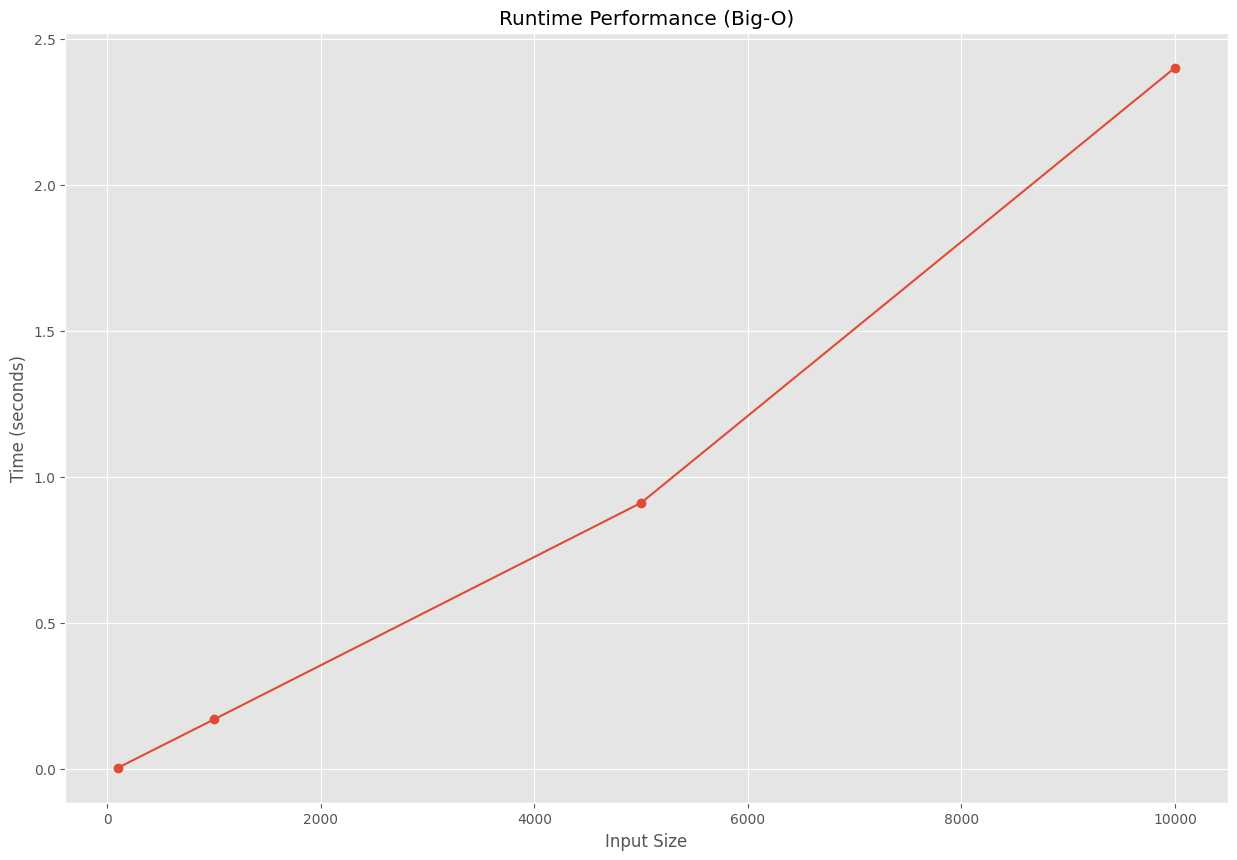

In [380]:
import time
import matplotlib.pyplot as plt
import numpy as np

def measure_runtime(func, inputs):
    runtimes = []
    for input_data in inputs:
        start_time = time.time()
        func(input_data)  
        end_time = time.time()
        runtimes.append(end_time - start_time)
    return runtimes

def call_function(n):
    model = KMeans(k=4)
    samples = np.random.choice(PCA_ds.values.shape[0], size=n, replace=True)  # 按行抽取
    samples = PCA_ds.values[samples]  
    model.fit(list(samples))

# Define input sizes
input_sizes  = [100,1000,5000,10000]

runtimes = measure_runtime(call_function, input_sizes)

# Plot Big-O runtime
plt.plot(input_sizes, runtimes, marker='o')
plt.title("Runtime Performance (Big-O)")
plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()

### 7.2 loop counter plot

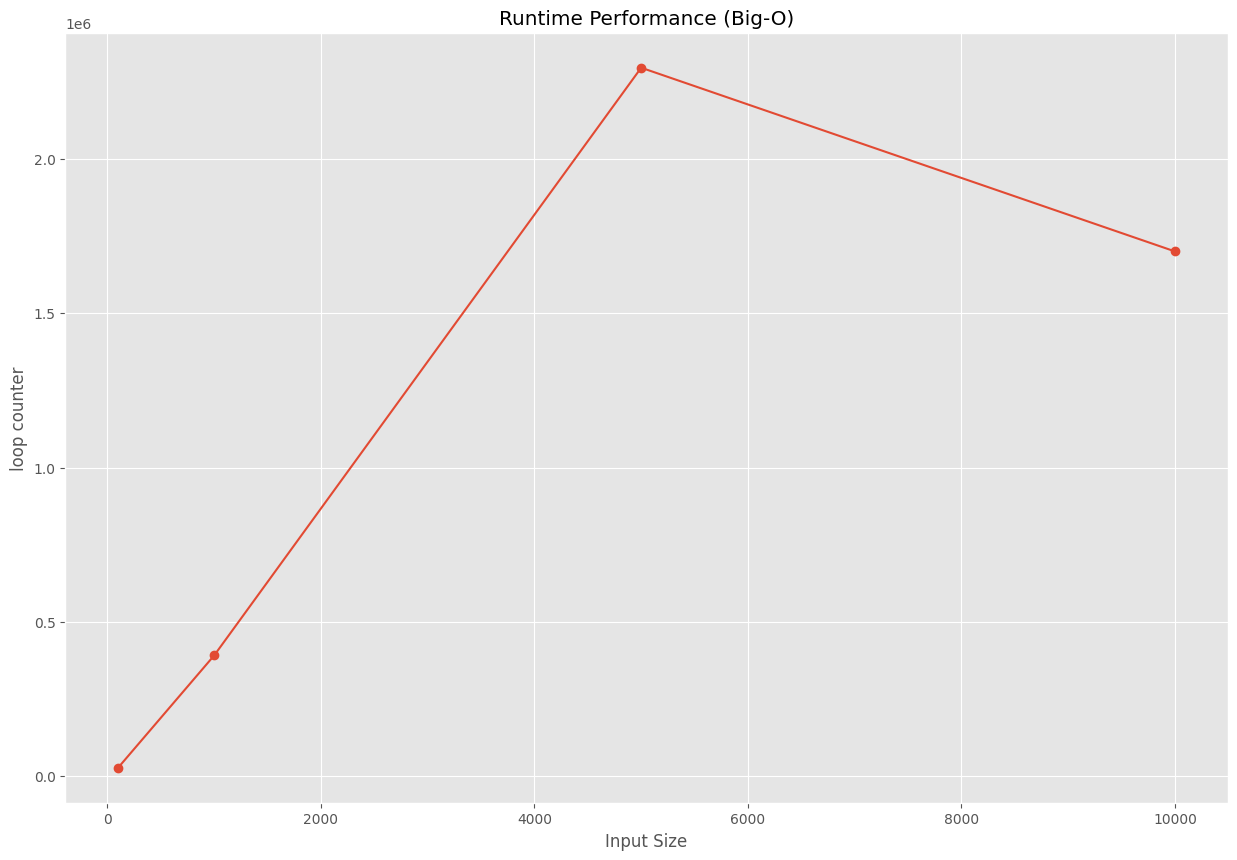

In [381]:
def measure_count(func, inputs):
    counters = []
    for input_data in inputs:
        counter = func(input_data)  
        counters.append(counter)
    return counters

def call_function(n):
    model = KMeans(k=4)
    samples = np.random.choice(PCA_ds.values.shape[0], size=n, replace=True)  # 按行抽取
    samples = PCA_ds.values[samples]  
    model.fit(list(samples))
    return model.counter

# Define input sizes
input_sizes  = [100,1000,5000,10000]

counters = measure_count(call_function, input_sizes)

# Plot Big-O runtime
plt.plot(input_sizes, counters, marker='o')
plt.title("Runtime Performance (Big-O)")
plt.xlabel("Input Size")
plt.ylabel("loop counter")
plt.grid(True)
plt.show()

### 7.3 Theoretical plot

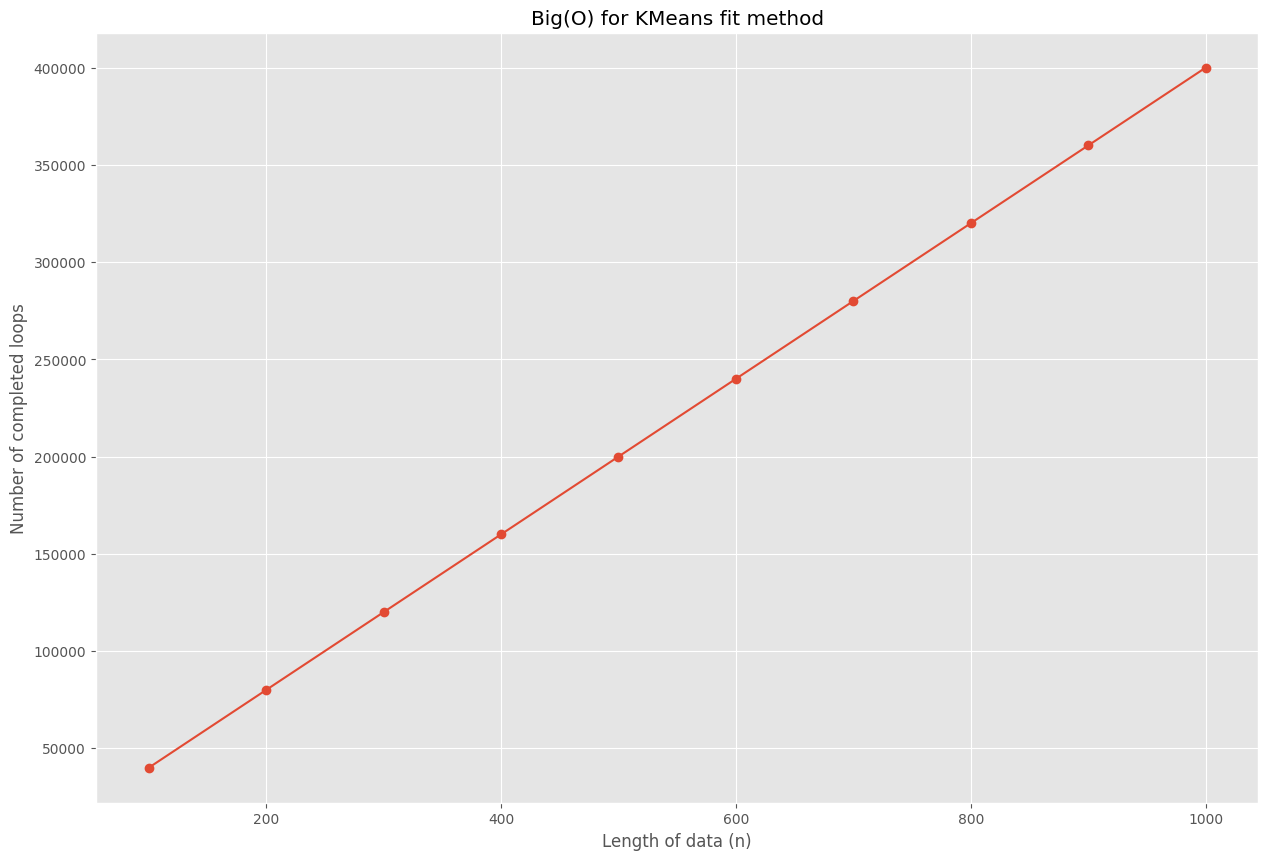

Bad pipe message: %s [b'\x95\xa1!}\xa7\xe21|\xa6\xf3.\xaa\xc9Z\xd6A\xec\xa8 \xb6\xc4\xe2\xe8\xfcX\x1dQ\xe5\x1d\xe1\x06\xb0(\x8b\xad\x8bI\xb21\x85jy\xfc@39H\x96\xfc\xea\x14\x00\x08\x13\x02\x13\x03\x13\x01\x00\xff\x01\x00\x00\x8f\x00\x00\x00\x0e\x00\x0c\x00\x00\t127.0.0.1\x00\x0b\x00\x04\x03\x00\x01\x02\x00\n\x00\x0c\x00\n\x00\x1d\x00\x17\x00\x1e\x00\x19\x00\x18\x00#\x00\x00\x00\x16\x00\x00\x00\x17\x00\x00\x00\r\x00\x1e\x00\x1c\x04\x03\x05\x03\x06\x03\x08\x07\x08\x08\x08\t\x08\n\x08\x0b\x08\x04\x08\x05\x08\x06\x04\x01\x05\x01\x06\x01\x00+\x00\x03\x02']
Bad pipe message: %s [b'\x00-']
Bad pipe message: %s [b"\xff\xa4\xc8\xe3U\xdeG\x94\x1e\xed\x8bN\x15-\x8d\xa7\xcc\x86\x00\x00\xa6\xc0,\xc00\x00\xa3\x00\x9f\xcc\xa9\xcc\xa8\xcc\xaa\xc0\xaf\xc0\xad\xc0\xa3\xc0\x9f\xc0]\xc0a\xc0W\xc0S\xc0+\xc0/\x00\xa2\x00\x9e\xc0\xae\xc0\xac\xc0\xa2\xc0\x9e\xc0\\\xc0`\xc0V\xc0R\xc0$\xc0(\x00k\x00j\xc0s\xc0w\x00\xc4\x00\xc3\xc0#\xc0'\x00g\x00@\xc0r\xc0v\x00\xbe\x00\xbd\xc0\n\xc0\x14\x009\x00", b'\x88\x00\x87\x

In [382]:
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = [15, 10]

nvals = [n for n in range(100, 1001, 100)]
loopvals = [ 100 * (n + 3*n ) for n in nvals]

# plot the graph
plt.xlabel('Length of data (n)')
plt.ylabel('Number of completed loops')
plt.title('Big(O) for KMeans fit method')
plt.plot(nvals, loopvals, 'o-')
plt.show()
